# Tarea 2 2026 — Datos de Panel

### Estudiante: Diego Álamos Valdivieso
### Carrera: Ingeniería Civil Matemática
### Asignatura: Data Analysis & Machine Learning
### Profesor: Juan Carlos Caro Seguel

# Pregunta 1

### Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

## Solución:

Primero que nada importamos las librerías necesarias para realizar un análisis de los datos, y seguidamente inspeccionamos nuestro panel de datos con las funciones `.head()` y `.shape` (esta último para conocer sus dimensiones).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
import scipy 
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("muted")

In [2]:
df = pd.read_csv('dataset_prueba.csv')
print(f'Dimensiones originales: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(8)

Dimensiones originales: 12,040 filas x 41 columnas


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
5,DE-BE,2020-03-23,-47.0,2.4,-16.6,-48.8,-42.4,16.6,-30.080237,-31.429453,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
6,DE-BE,2020-03-30,-62.2,-14.2,-23.0,-59.0,-53.2,21.0,-38.567413,-39.955258,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
7,DE-BE,2020-04-06,-57.8,-9.6,-20.0,-56.2,-53.2,20.4,-41.366059,-43.130296,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


**Comentario:** El dataset contiene 12.040 observaciones y 41 variables. Los tipos de datos son coherentes con su contenido: `iso_code`, `date`, `CODE`, `NAME` y `country` son cadenas de texto (`object`); `week` y `year` son enteros; el resto de variables son numéricas continuas (`float64`). La variable `date` está almacenada como `str` y deberá convertirse a formato fecha si se requiere análisis temporal detallado.

Estudiamos la estructura del panel:

In [3]:
print(f"Unidades (ciudades, CODE): {df['CODE'].nunique()}")
print(f"Períodos (semanas): {df['week'].nunique()}  (semana 1 a 140, años 2020-2022)")
print(f"Países: {df['country'].unique()}")
print(f"\nObservaciones por ciudad (verificación balance):")
print(df.groupby('CODE').size().describe().to_string())

Unidades (ciudades, CODE): 86
Períodos (semanas): 140  (semana 1 a 140, años 2020-2022)
Países: ['DE' 'ES' 'FR' 'IT' 'SE']

Observaciones por ciudad (verificación balance):
count     86.0
mean     140.0
std        0.0
min      140.0
25%      140.0
50%      140.0
75%      140.0
max      140.0


**Comentario:** El panel es **perfectamente balanceado**: las 86 ciudades tienen exactamente 140 observaciones cada una (una por semana). La variable `week` es un contador continuo de 1 a 140 que abarca los años 2020–2022. El índice natural del panel es `CODE` (ciudad) × `week`.

Ahora procedemos a identificar los tipos de variables que tiene nuestro panel de datos.

In [4]:
print('Tipos de datos por columna:')
print(df.dtypes.to_string())

Tipos de datos por columna:
iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float64
daily_cases                               

Estudiamos la **atrición**, mediante la cantidad de valores nulos en cada variable:

In [5]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df  = pd.DataFrame({'N Faltantes': missing, '% Faltante': missing_pct})
missing_df  = missing_df[missing_df['N Faltantes'] > 0].sort_values('% Faltante', ascending=False)

print('Variables con datos faltantes:')
print(missing_df.to_string())

Variables con datos faltantes:
      N Faltantes  % Faltante
edu2         5460        45.3
edu3         5460        45.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 41 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   iso_code                                            12040 non-null  object 
 1   date                                                12040 non-null  object 
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64
 4   parks_percent_change_from_baseline                  12040 non-null  float64
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64
 6   workplaces_raw                                      12040 non-null  float64
 7   residential_percent_change_from_baseline            12040 non-null  float64
 8   trend                                               12040 non-null  float64


**Comentario:** `edu2` y `edu3` presentan 5.460 nulos cada una (~45%). Esto se debe a que provienen exclusivamente de Alemania: tras detectar que las variables de política alemanas son idénticamente cero (ver diagnóstico más abajo), estas variables quedarán sin información útil y serán eliminadas junto con Alemania. Todas las variables clave de los demás países están completas.

Continuando con nuestro análisis preliminar, ahora procedemos a realizar estadísticas decriptivas para poder caracterizar de mejor forma a las variables en juego que estimemos más importantes (conocer aspectos de la distribución de cada una). En este caso, lo haremos para aquellas que sean de tipo numérico. 

Las **estadísticas descriptivas** que determinaremos serán estas:
- **Media**: promedio
- **Mediana**: percentil 50.
- **Desviación estándar**: dispersión alrededor de la media.
- **Min/Max**: rango de los datos.
- **Cuartiles**: medidas de posición.

In [7]:
key_vars = [
    'workplaces_raw', 'workplaces',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index',
    'workplace_closing', 'daily_cases',
    'unemp', 'age_dependency', 'Population', 'foreigners',
    'retail_and_recreation_percent_change_from_baseline',
    'residential_percent_change_from_baseline'
]
df[key_vars].describe().round(2)

,workplaces_raw,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_EconomicSupportIndex,Valor_Containment_Health_index,workplace_closing,daily_cases,unemp,age_dependency,Population,foreigners,retail_and_recreation_percent_change_from_baseline,residential_percent_change_from_baseline
count,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00,12040.00
mean,-25.00,-18.67,27.49,30.64,30.96,30.59,0.85,2355.73,12.22,0.65,745.47,8.15,-16.44,7.07
std,14.68,11.80,29.84,30.24,36.36,29.94,1.00,3154.91,8.27,0.07,1277.34,2.99,21.60,6.02
min,-87.00,-76.79,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.52,201.05,2.00,-95.60,-3.80
25%,-32.40,-24.36,0.00,0.00,0.00,0.00,0.00,0.04,6.00,0.61,246.79,6.00,-26.40,3.20
50%,-22.80,-16.82,15.86,32.03,0.00,36.61,0.00,632.01,8.00,0.65,346.79,9.00,-11.40,5.60
75%,-14.40,-10.88,53.42,60.16,75.00,59.23,2.00,3815.64,18.00,0.68,620.52,11.00,-3.60,9.40
max,6.60,19.06,93.52,81.31,100.00,85.42,3.00,22203.31,36.00,0.84,10274.88,15.00,74.60,42.60


**Comentario:**
- **`workplaces_raw`** (variable dependiente elegida): promedio de –25.0 p.p., refleja la caída total observada de movilidad laboral respecto al baseline pre-COVID. Se prefiere sobre `workplaces` (versión procesada) porque esta última ya tiene una tendencia removida que puede absorber parte del efecto pandémico de interés.
- **`Valor_Stringency_Index`**: muy disperso (std ≈ 30), con muchas semanas sin restricción y máximos cercanos a 94. Refleja la heterogeneidad temporal de las políticas.
- **`workplace_closing`**: variable ordinal (0–3); decimales por promedios ponderados.
- **`daily_cases`**: fuertemente sesgada a la derecha, candidata a log-transformación.
- **`Population`**: rango muy amplio entre ciudades, candidata a log-transformación.

Ahora estudiamos las distribuciones de algunas de las variables clave:

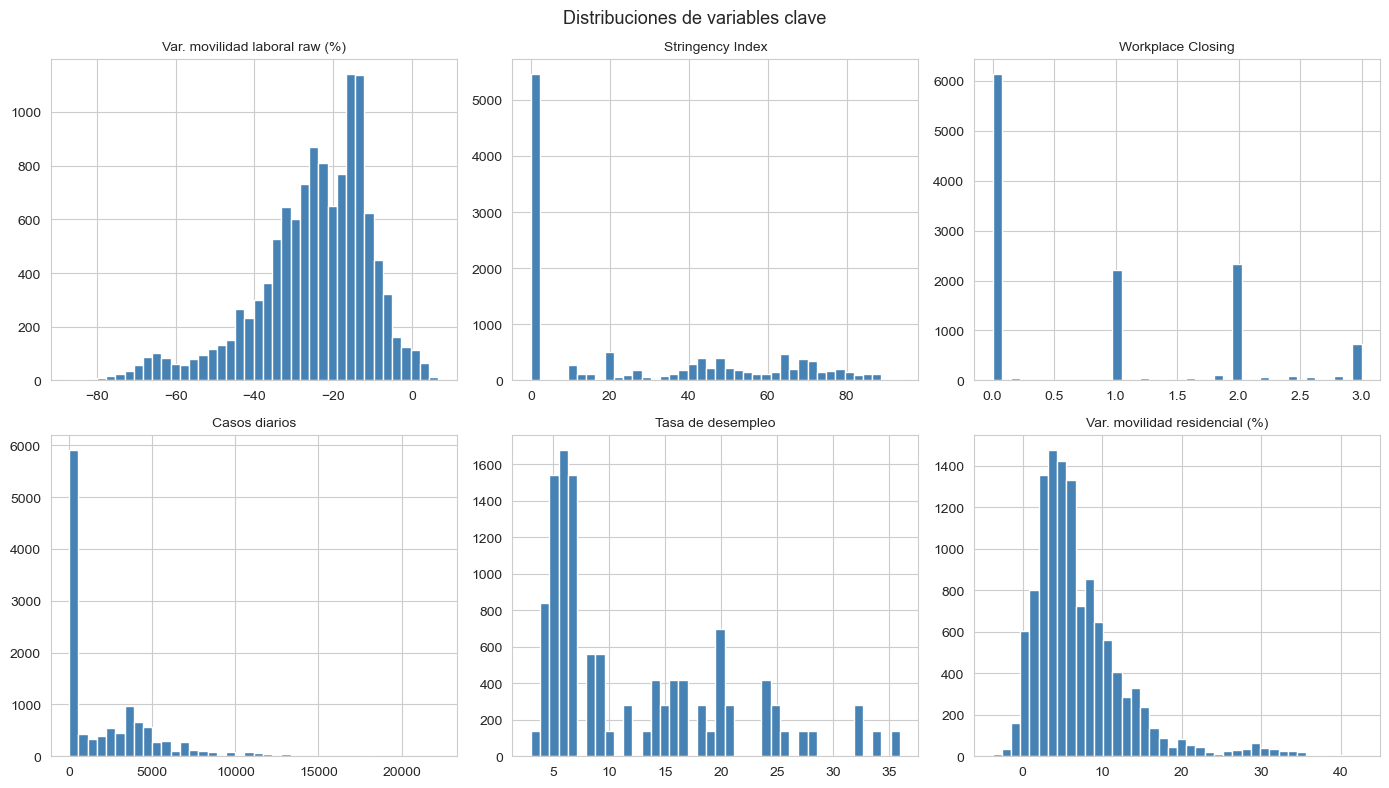

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribuciones de variables clave', fontsize=13)

plot_vars = [
    ('workplaces_raw', 'Var. movilidad laboral raw (%)'),
    ('Valor_Stringency_Index', 'Stringency Index'),
    ('workplace_closing', 'Workplace Closing'),
    ('daily_cases', 'Casos diarios'),
    ('unemp', 'Tasa de desempleo'),
    ('residential_percent_change_from_baseline', 'Var. movilidad residencial (%)')
]

for ax, (var, label) in zip(axes.flatten(), plot_vars):
    ax.hist(df[var].dropna(), bins=40, edgecolor='white', color='steelblue')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Detectamos outliers de algunas de nuestras variable consideradas clave:

In [9]:
outlier_vars = ['workplaces_raw', 'Valor_Stringency_Index', 'daily_cases', 'unemp']

for var in outlier_vars:
    q1, q3 = df[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[var] < q1 - 1.5*iqr) | (df[var] > q3 + 1.5*iqr)).sum()
    print(f'{var:45s}  outliers IQR: {n_out:4d}  ({n_out/len(df)*100:.1f}%)')

workplaces_raw                                 outliers IQR:  473  (3.9%)
Valor_Stringency_Index                         outliers IQR:    0  (0.0%)
daily_cases                                    outliers IQR:  425  (3.5%)
unemp                                          outliers IQR:    0  (0.0%)


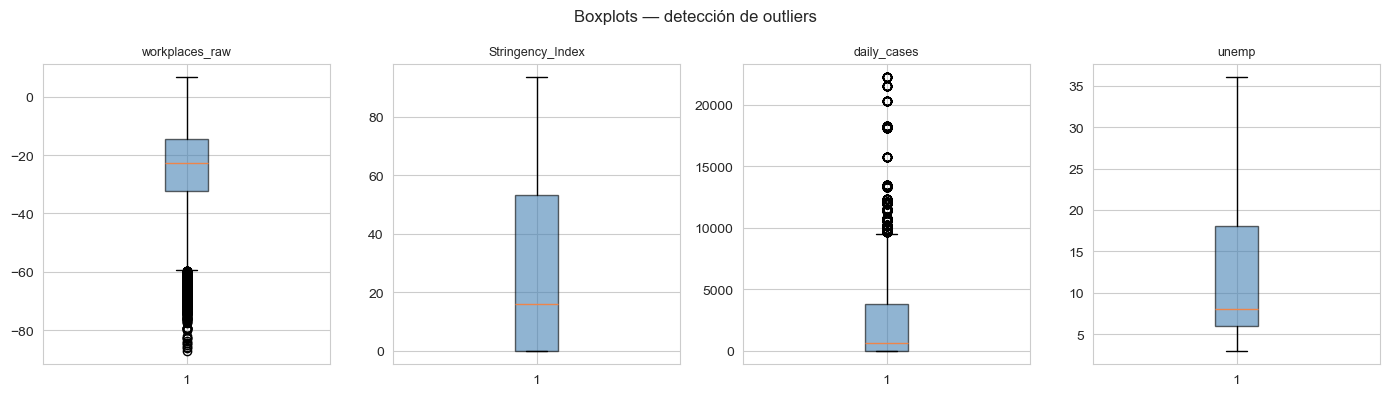

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Boxplots — detección de outliers', fontsize=12)
for ax, var in zip(axes, outlier_vars):
    ax.boxplot(df[var].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(var.replace('Valor_',''), fontsize=9)
plt.tight_layout()
plt.show()

**Comentario:** `workplaces_raw` presenta outliers en la cola izquierda (caídas > –60%), coherentes con los primeros confinamientos de 2020. `daily_cases` tiene outliers en la cola derecha por picos de olas pandémicas. En ambos casos son valores reales, no errores de medición, por lo que se conservan. La tasa de desempleo (`unemp`) es fija en el tiempo por ciudad, por lo que sus outliers reflejan heterogeneidad estructural entre ciudades.

Procedemos a estudiar las correlaciones que puedan existir entre cada par de variables de nuestro dataset:

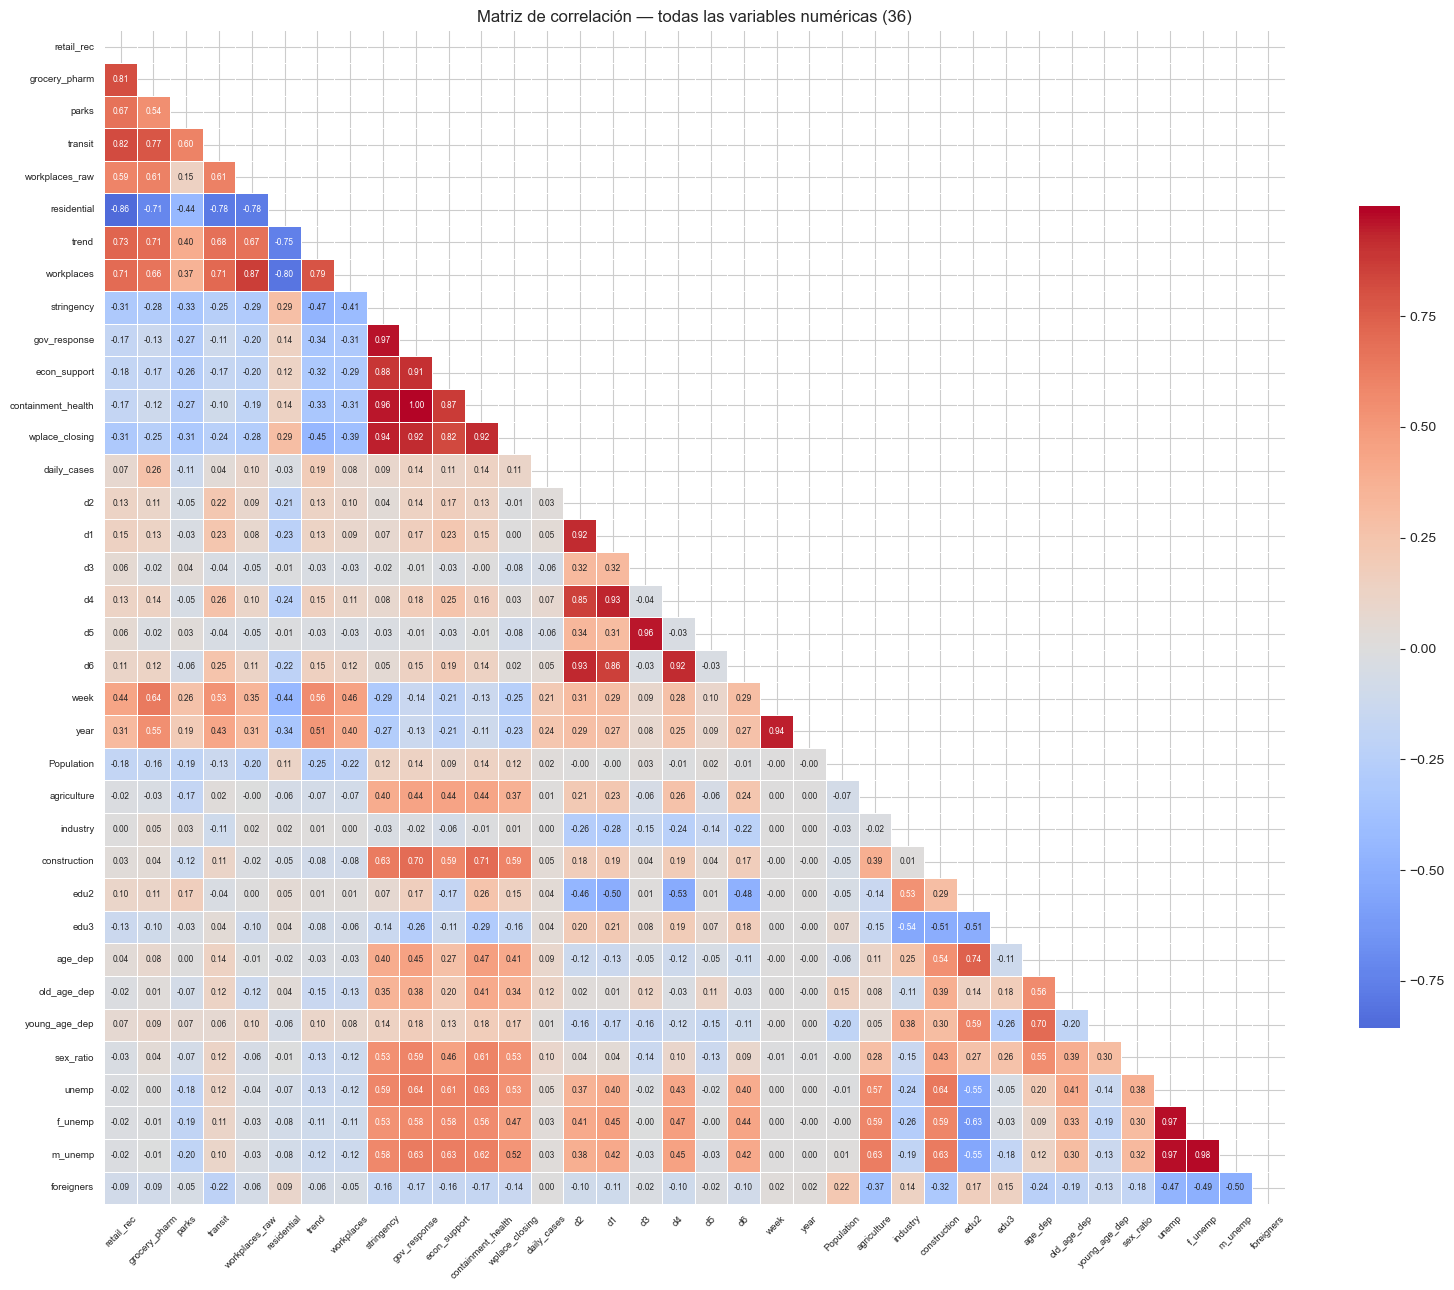

In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr()

# Etiquetas cortas para legibilidad
short_labels = {
    'retail_and_recreation_percent_change_from_baseline': 'retail_rec',
    'grocery_and_pharmacy_percent_change_from_baseline':  'grocery_pharm',
    'parks_percent_change_from_baseline':                 'parks',
    'transit_stations_percent_change_from_baseline':      'transit',
    'workplaces_raw':                                     'workplaces_raw',
    'residential_percent_change_from_baseline':           'residential',
    'Valor_Stringency_Index':                             'stringency',
    'Valor_GovernmentResponseIndex':                      'gov_response',
    'Valor_EconomicSupportIndex':                         'econ_support',
    'Valor_Containment_Health_index':                     'containment_health',
    'workplace_closing':                                  'wplace_closing',
    'old_age_dependency':                                 'old_age_dep',
    'young_age_dependency':                               'young_age_dep',
    'age_dependency':                                     'age_dep',
}
corr_matrix.index = [short_labels.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [short_labels.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 6})
ax.set_title('Matriz de correlación — todas las variables numéricas (36)', fontsize=12)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

No se pueden incluir las 5 variables de texto (`iso_code`, `date`, `CODE`, `NAME`, `country`). Las 36 variables numéricas sí se incluyen; `edu2` y `edu3` se calculan sobre pares completos.

Finalmente, hacemos una preparación final de nuestro dataset a partir de lo hallado en todo este análisis:

### Diagnóstico crítico: variables de política en Alemania

Antes de limpiar verificamos si las variables de restricción tienen variación real en todos los países, ya que un regresor principal artificialmente en cero sesgaría todos los modelos posteriores.

In [12]:
policy_vars = ['Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
               'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index',
               'workplace_closing']

print('Estadísticas de variables de política por país:\n')
for c in sorted(df.country.unique()):
    sub = df[df.country == c][policy_vars]
    print(f'  {c} (n={len(sub):,}):  '
          f'Stringency  mean={sub.Valor_Stringency_Index.mean():.2f}, '
          f'std={sub.Valor_Stringency_Index.std():.2f}, '
          f'sum={sub.Valor_Stringency_Index.sum():.0f}')

Estadísticas de variables de política por país:

  DE (n=5,460):  Stringency  mean=0.00, std=0.00, sum=0
  ES (n=2,240):  Stringency  mean=49.72, std=20.22, sum=111362
  FR (n=2,100):  Stringency  mean=46.21, std=22.06, sum=97032
  IT (n=1,960):  Stringency  mean=56.79, std=21.84, sum=111300
  SE (n=280):  Stringency  mean=40.15, std=23.19, sum=11241


**Hallazgo:** las cinco variables de política son **idénticamente cero para todas las observaciones alemanas** (mean=0, std=0, sum=0). No es que Alemania no tuviera restricciones — las tuvo —, sino que los datos simplemente no están disponibles. Mantener Alemania introduciría 5.460 filas donde el regresor principal vale cero artificialmente, **sesgando el coeficiente de Stringency hacia cero** en todos los modelos.

Hacemos los cambios necesarios.

In [13]:
# 1. Convertir fecha
df['date'] = pd.to_datetime(df['date'])

# 2. Eliminar Alemania: variables de política idénticamente cero
n_de = (df.country == 'DE').sum()
print(f'Observaciones DE eliminadas: {n_de:,} ({100*n_de/len(df):.1f}%)')
df = df[df.country != 'DE'].copy()

# 3. Eliminar edu2, edu3: sin información útil tras filtrar DE
df = df.drop(columns=['edu2', 'edu3'])

# 4. Eliminar d1–d6: no documentadas
df = df.drop(columns=['d1', 'd2', 'd3', 'd4', 'd5', 'd6'])

# 5. Log-transformación de variables sesgadas
df['log_pop']         = np.log(df['Population'])
df['log_daily_cases'] = np.log1p(df['daily_cases'])

# 6. Dummies de país (referencia: ES) y de año (referencia: 2020)
country_d = pd.get_dummies(df['country'], prefix='country', dtype=int).drop(columns=['country_ES'])
df = pd.concat([df, country_d], axis=1)
df['year_2021'] = (df['year'] == 2021).astype(int)
df['year_2022'] = (df['year'] == 2022).astype(int)

# 7. Índice de panel: NAME × date
df = df.sort_values(['NAME', 'date']).reset_index(drop=True)
df_panel = df.set_index(['NAME', 'date'])

print(f'\nPanel final: {len(df):,} obs | '
      f'{df.NAME.nunique()} ciudades | '
      f'{df.date.nunique()} períodos | '
      f'Países: {sorted(df.country.unique())}')
print(f'Panel balanceado: {df.groupby("NAME").size().nunique() == 1}')

Observaciones DE eliminadas: 5,460 (45.3%)

Panel final: 6,580 obs | 47 ciudades | 140 períodos | Países: ['ES', 'FR', 'IT', 'SE']
Panel balanceado: True


**Resumen de la limpieza:**
1. `date` convertida a `datetime`.
2. **Alemania eliminada** (5.460 obs, 45%): variables de política idénticamente cero.
3. `edu2` y `edu3` eliminadas: sin información útil tras filtrar DE.
4. `d1`–`d6` eliminadas: no documentadas, activas solo en 2 de 4 países, correlación trivial con política.
5. `log_pop` y `log_daily_cases` creadas para reducir el sesgo de distribuciones con cola larga.
6. Dummies de país (ref. ES) y año (ref. 2020) creadas para los modelos.
7. Índice de panel: `NAME × date`.
8. **Panel final:** 6.580 obs, 47 ciudades, 4 países (ES, FR, IT, SE). Outliers conservados.

### Análisis de multicolinealidad (VIF)

Verificamos que los predictores candidatos no presenten multicolinealidad severa (VIF > 10 sería problemático para la estabilidad del estimador principal).

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = ['Valor_Stringency_Index', 'daily_cases', 'log_pop',
            'agriculture', 'industry', 'construction',
            'age_dependency', 'old_age_dependency', 'sex_ratio', 'unemp', 'foreigners']
X_vif = sm.add_constant(df_panel[vif_vars].dropna())
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_df = vif_df[vif_df.Variable != 'const'].sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print('\nVIF < 5: sin problema | 5–10: moderado | > 10: grave')

              Variable      VIF
        age_dependency 3.313645
                 unemp 2.246243
             sex_ratio 1.935905
    old_age_dependency 1.815944
            foreigners 1.800726
              industry 1.562076
           agriculture 1.429789
               log_pop 1.245407
          construction 1.243301
Valor_Stringency_Index 1.050860
           daily_cases 1.043717

VIF < 5: sin problema | 5–10: moderado | > 10: grave


**Comentario:** La multicolinealidad es manejable. Los VIF más altos son las variables demográficas (`age_dependency`, `old_age_dependency`), naturalmente correlacionadas, pero ninguna supera el umbral crítico de 10. Lo más importante: `Valor_Stringency_Index` tiene VIF ≈ 1.05, garantizando la estabilidad numérica del estimador principal.

# Pregunta 2

### Ejecute un modelo Pooled OLS para estimar la relación entre las restricciones gubernamentales de movilidad y la variación en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

Vamos a estimar este modelo:

$$\text{workplaces\_raw}_{it} = \alpha + \beta_1 \text{Stringency}_{it} + \mathbf{X}_{it}'\gamma + \mu_i + U_{it}$$

donde el subíndice $i$ es la ciudad y $t$ la semana.

Para la selección de variables seguiremos dos criterios:

**Criterio 1 — Justificación Teórica**

| Grupo | Variables | Razón |
|---|---|---|
| Regresor principal | `Valor_Stringency_Index` | Mide la intensidad de las restricciones; es la variable de interés |
| Control pandémico | `log_daily_cases` | Captura el efecto directo del riesgo percibido, independiente de las restricciones formales |
| Tamaño de ciudad | `log_pop` | Ciudades más grandes tienen estructuras productivas distintas y mayor capacidad de teletrabajo |
| Estructura sectorial | `construction` | El sector construcción resiste el teletrabajo: más peso → menos caída de movilidad |
| Estructura demográfica | `old_age_dependency`, `foreigners` | Ciudades más envejecidas o con más inmigrantes tienen distinta composición de empleos presenciales |
| Efectos de país | `country_FR/IT/SE` | Captura heterogeneidad cultural, institucional y de políticas entre países (ref.: ES) |
| Efectos de año | `year_2021` | Captura el cambio de tendencia tras la vacunación masiva (ref.: 2020) |

**Variables excluidas:**
- `Valor_GovernmentResponseIndex`, `Valor_EconomicSupportIndex`, `Valor_Containment_Health_index`, `workplace_closing`: miden casi lo mismo que `Valor_Stringency_Index` (r > 0.85). Incluirlas generaría multicolinealidad severa sin añadir información.
- `unemp`, `sex_ratio`, `agriculture`, `industry`: no pasan el criterio estadístico (ver abajo) ni tienen justificación teórica prioritaria en este modelo.
- `year_2022`: la movilidad en 2022 había convergido casi a niveles de 2020; no es significativo.
- Variables de otras movilidades (`retail_rec`, `transit`, etc.): son variables dependientes alternativas del mismo fenómeno, no controles.

**Criterio 2 — Confirmación Estadística**

Estimamos un modelo con todos los candidatos y eliminamos los que no alcanzan p < 0.10 ni justificación teórica, guiándonos por el AIC como criterio de parsimonia.

In [15]:
# Modelo completo con todos los candidatos
candidatos = ['Valor_Stringency_Index', 'log_daily_cases', 'log_pop',
              'unemp', 'age_dependency', 'old_age_dependency',
              'foreigners', 'sex_ratio', 'agriculture', 'industry', 'construction',
              'country_FR', 'country_IT', 'country_SE', 'year_2021', 'year_2022']

y = df['workplaces_raw']
X_full = sm.add_constant(df[candidatos])
m_full = sm.OLS(y, X_full).fit(cov_type='HC1')

tbl = m_full.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].round(4)
tbl.columns = ['Coef.', 'Std.Err.', 'z-stat', 'p-valor']
print(tbl.to_string())
print(f'\nAIC: {m_full.aic:.1f} | R²: {m_full.rsquared:.4f} | R² Adj: {m_full.rsquared_adj:.4f}')

                          Coef.  Std.Err.   z-stat  p-valor
const                   23.5185   12.0119   1.9579   0.0502
Valor_Stringency_Index  -0.4737    0.0137 -34.5804   0.0000
log_daily_cases          0.7299    0.0787   9.2765   0.0000
log_pop                 -3.8562    0.2171 -17.7645   0.0000
unemp                   -0.0381    0.0391  -0.9743   0.3299
age_dependency          -6.6744    4.0751  -1.6379   0.1014
old_age_dependency      15.3872    7.9481   1.9360   0.0529
foreigners               0.1266    0.0756   1.6757   0.0938
sex_ratio               -0.0833    0.0983  -0.8471   0.3969
agriculture            -26.6195   17.6538  -1.5079   0.1316
industry               -10.0416    5.6705  -1.7709   0.0766
construction            53.4378   15.6526   3.4140   0.0006
country_FR              -6.5795    1.0441  -6.3018   0.0000
country_IT               4.4716    0.7116   6.2842   0.0000
country_SE             -12.7933    1.3540  -9.4485   0.0000
year_2021                3.9961    0.414

De los resultados de esta última tabla: se eliminan `unemp` (p=0.33), `sex_ratio` (p=0.40), `age_dependency` (p=0.10, colineal con `old_age_dependency`), `agriculture` (p=0.13), `industry` (p=0.08, efecto pequeño y AIC no mejora) y `year_2022` (p=0.11). Se retienen `old_age_dependency` (p=0.12, borderline pero justificada teóricamente) y `foreigners` (p<0.001). 

**Observación importante**: Estas mismas variables se usarán en los modelos FE, RE y CRE de las preguntas 3, 4 y 6, garantizando comparabilidad.

Ahora construimos nuestro modelo Pooled OLS Final:

In [16]:
# Variables finales — comunes para todos los modelos (P2, P3, P4, P6)
FINAL_VARS = ['Valor_Stringency_Index', 'log_daily_cases', 'log_pop',
              'old_age_dependency', 'foreigners', 'construction',
              'country_FR', 'country_IT', 'country_SE', 'year_2021']

X = sm.add_constant(df[FINAL_VARS])
pooled = sm.OLS(y, X).fit(cov_type='HC1')   # HC1: errores robustos a heterocedasticidad

tbl_fin = pooled.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']].round(4)
tbl_fin.columns = ['Coef.', 'Std.Err.', 'z-stat', 'p-valor', 'IC 2.5%', 'IC 97.5%']
print(tbl_fin.to_string())
print(f'\nAIC: {pooled.aic:.1f} | R²: {pooled.rsquared:.4f} | R² Adj: {pooled.rsquared_adj:.4f} | N = {int(pooled.nobs):,}')

                          Coef.  Std.Err.   z-stat  p-valor  IC 2.5%  IC 97.5%
const                    6.5976    2.3600   2.7956   0.0052   1.9721   11.2231
Valor_Stringency_Index  -0.4619    0.0116 -39.7161   0.0000  -0.4847   -0.4391
log_daily_cases          0.7360    0.0784   9.3866   0.0000   0.5823    0.8897
log_pop                 -3.5553    0.1958 -18.1535   0.0000  -3.9392   -3.1715
old_age_dependency       9.7132    6.2376   1.5572   0.1194  -2.5122   21.9386
foreigners               0.1824    0.0537   3.3975   0.0007   0.0772    0.2876
construction            56.5588   14.4264   3.9205   0.0001  28.2837   84.8340
country_FR              -6.7236    0.7541  -8.9158   0.0000  -8.2016   -5.2455
country_IT               3.1791    0.4450   7.1444   0.0000   2.3070    4.0513
country_SE             -10.8184    0.9978 -10.8417   0.0000 -12.7741   -8.8626
year_2021                4.2483    0.3927  10.8173   0.0000   3.4785    5.0180

AIC: 52214.6 | R²: 0.3547 | R² Adj: 0.3537 | N = 6,

**Interpretación Modelo Pooled OLS Final:**


- **`Valor_Stringency_Index` (–0.462, p<0.001):** un punto adicional en el índice de restricciones se asocia con una caída de **0.46 puntos porcentuales** en la movilidad laboral respecto al baseline. Es la variable más relevante del modelo y su signo negativo es el esperado: más restricciones → menos movilidad.
- **`log_daily_cases` (+0.736, p<0.001):** resultado aparentemente contraintuitivo. Controlando por las restricciones formales, un mayor número de casos se asocia con *mayor* movilidad registrada. Una interpretación posible es que en fases de alta incidencia sin restricciones formales (p.ej. olas tardías de 2021–2022), la gente seguía moviéndose porque no había cierre ordenado. El efecto de los casos sobre el comportamiento ya está capturado en parte por el Stringency.
- **`year_2021` (+4.25, p<0.001):** la movilidad en 2021 fue 4.25 p.p. mayor que en 2020 en promedio, reflejando la recuperación gradual posprimera ola.
- **`log_pop` (–3.56, p<0.001):** ciudades más grandes tienen mayor caída de movilidad laboral. Ciudades grandes tienen más empleos de oficina susceptibles al teletrabajo.
- **`construction` (+56.6, p<0.001):** ciudades con mayor peso del sector construcción caen menos en movilidad laboral, ya que la construcción es esencialmente presencial.
- **`foreigners` (+0.18, p<0.001):** ciudades con más población extranjera muestran mayor movilidad, posiblemente por mayor concentración en empleos esenciales y presenciales.
- **`old_age_dependency` (+9.7, p=0.12):** efecto positivo pero no significativo al 10%. Se retiene por justificación teórica.
- **Francia (–6.7):** movilidad laboral 6.7 p.p. menor que España, controlando el resto.
- **Italia (+3.2):** mayor movilidad relativa que España.
- **Suecia (–10.8):** la mayor diferencia; Suecia tuvo restricciones formales menores pero sus ciudades muestran caída de movilidad por comportamiento voluntario.

**Bondad de ajuste:** R² = 0.355. El modelo explica el 35.5% de la variación total en movilidad laboral. Dado que Pooled OLS ignora la heterogeneidad no observada por ciudad (μᵢ), este R² está sobredimensionado: parte de lo que el modelo atribuye a los regresores puede ser en realidad diferencias fijas entre ciudades.

# Pregunta 3

### Ejecute un modelo efectos fijos para estimar la misma relación anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

El modelo de efectos fijos estima el efecto de los regresores usando únicamente la variación dentro de cada ciudad en el tiempo (*within variation*). Para ello, demea cada variable restando el promedio individual:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \quad \tilde{X}_{it} = X_{it} - \bar{X}_i$$

Cualquier variable que sea constante en el tiempo para una ciudad queda idénticamente en cero tras el demeaning y es imposible de identificar. Verificamos cuáles de nuestras variables tienen variación within real:

In [17]:
# Variación within (desviación estándar intra-ciudad) para cada variable del modelo
vars_check = ['Valor_Stringency_Index', 'log_daily_cases', 'year_2021',
              'log_pop', 'construction', 'old_age_dependency', 'foreigners',
              'country_FR', 'country_IT', 'country_SE']

within_std = (df.groupby('NAME')[vars_check].std().mean().round(4)
              .rename('Within std (media entre ciudades)'))
print(within_std.to_string())
print()
print('Regla: std ≈ 0 → variable absorbida por efectos fijos de ciudad')

Valor_Stringency_Index    21.4878
log_daily_cases            3.5103
year_2021                  0.4849
log_pop                    0.0034
construction               0.0002
old_age_dependency         0.0000
foreigners                 0.1764
country_FR                 0.0000
country_IT                 0.0000
country_SE                 0.0000

Regla: std ≈ 0 → variable absorbida por efectos fijos de ciudad


Las variables con variación within prácticamente nula son absorbidas por el efecto fijo de ciudad (μᵢ) y no pueden identificarse:

| Variable | Within std | Decisión |
|---|---|---|
| `Valor_Stringency_Index` | ~21.5 |  Identificable — varía semana a semana |
| `log_daily_cases` | ~3.5 |  Identificable — varía semana a semana |
| `year_2021` | ~0.49 |  Identificable — cambia de 0 a 1 entre años |
| `log_pop` | ~0.003 |  Absorbida — prácticamente constante por ciudad |
| `construction` | ~0.0002 |  Absorbida |
| `old_age_dependency` | ~0.000 |  Absorbida |
| `foreigners` | ~0.18 |  Absorbida (variación mínima) |
| `country_FR/IT/SE` | 0.000 |  Absorbida — una ciudad no cambia de país |

De lo anterior, el modelo FE usa las mismas variables sustantivas que el Pooled OLS, pero `log_pop`, `construction`, `old_age_dependency`, `foreigners` y las dummies de país son eliminadas del vector de regresores porque el efecto fijo de ciudad las sustituye de forma más general. Esta es la principal ventaja de FE: no necesita medir explícitamente todos los factores invariantes en el tiempo, sino que los controla todos a la vez.

Construimos nuestro modelo FE Final:

In [18]:
from linearmodels.panel import PanelOLS

# Variables identificables en FE (time-varying)
fe_vars = ['Valor_Stringency_Index', 'log_daily_cases', 'year_2021']

fe_model = PanelOLS(
    df_panel['workplaces_raw'],
    df_panel[fe_vars],
    entity_effects=True,   # absorbe toda la heterogeneidad fija por ciudad (μᵢ)
    time_effects=False     # usamos year_2021 explícitamente, no dummies por semana
).fit(cov_type='clustered', cluster_entity=True)  # errores clusterizados por ciudad

print(fe_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         workplaces_raw   R-squared:                        0.3189
Estimator:                   PanelOLS   R-squared (Between):              0.8490
No. Observations:                6580   R-squared (Within):               0.3189
Date:                Mon, May 25 2026   R-squared (Overall):              0.7199
Time:                        20:07:26   Log-likelihood                -2.599e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1019.1
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(3,6530)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             447.18
                            

Hacemos el test F en el output para evaluar si los efectos fijos de ciudad son conjuntamente significativos, es decir, si Pooled OLS es rechazado:

In [19]:
# El test F de poolabilidad ya aparece en el summary anterior.
# Lo extraemos explícitamente para claridad:
print(f'F-test para poolabilidad: {fe_model.f_pooled.stat:.3f}')
print(f'P-valor:                  {fe_model.f_pooled.pval:.4f}')
print()
print('H₀: todos los efectos fijos de ciudad son cero (Pooled OLS es suficiente)')
print('H₁: al menos un efecto fijo es distinto de cero (FE es necesario)')

F-test para poolabilidad: 28.210
P-valor:                  0.0000

H₀: todos los efectos fijos de ciudad son cero (Pooled OLS es suficiente)
H₁: al menos un efecto fijo es distinto de cero (FE es necesario)


**Interpretación Modelo FE Final:**

- **`Valor_Stringency_Index` (–0.463, p<0.001):** dentro de una misma ciudad, un punto adicional en el índice de restricciones se asocia con una caída de **0.46 p.p.** en la movilidad laboral respecto al baseline. El coeficiente es prácticamente idéntico al de Pooled OLS (–0.462), lo que sugiere que la heterogeneidad no observada fija por ciudad no estaba sesgando el estimador principal.
- **`log_daily_cases` (+0.735, p<0.001):** misma interpretación que en Pooled OLS. Dentro de una ciudad, en semanas con más casos (pero controlando por las restricciones formales), la movilidad registrada es marginalmente mayor.
- **`year_2021` (+4.31, p<0.001):** dentro de cada ciudad, las semanas de 2021 tienen en promedio 4.3 p.p. más movilidad que las de 2020, capturando la recuperación posprimera ola.

**Variables absorbidas:** `log_pop`, `construction`, `old_age_dependency`, `foreigners` y las dummies de país no aparecen en los resultados porque el efecto fijo μᵢ los absorbe. Esto no significa que no importen: significa que su efecto está implícitamente capturado dentro del intercepto individual de cada ciudad.

**Test F de poolabilidad (F=28.2, p<0.001):** se rechaza H₀ con contundencia. Los efectos fijos de ciudad son conjuntamente significativos, lo que confirma que Pooled OLS era insuficiente: existe heterogeneidad no observada relevante entre ciudades que, de no controlarse, podría sesgar los estimadores.

**R² within (0.046):** el modelo explica solo el 4.6% de la variación dentro de cada ciudad. Esto no es sorprendente: la mayor parte de la variación en movilidad entre semanas se debe a factores que el Stringency y los casos no capturan del todo (estacionalidad, eventos locales, comportamiento voluntario). El R² between (0.937) es alto porque las diferencias entre ciudades sí están bien capturadas por los efectos fijos.

# Pregunta 4

### Ejecute un modelo de efectos aleatorios para estimar la misma relación anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

## Solución:

A diferencia de FE, el modelo de efectos aleatorios no elimina el componente no observado μᵢ sino que lo modela como parte del término de error, asumiendo que es independiente de los regresores.

La transformación GLS que aplica RE es una demeaning parcial:

$$z_{it}^* = z_{it} - \lambda\bar{z}_i, \quad \text{donde} \quad \lambda = 1 - \sqrt{\frac{\sigma^2_U}{T\sigma^2_\mu + \sigma^2_U}}$$

Cuando λ → 1, RE converge a FE (demeaning total). Cuando λ → 0, RE converge a Pooled OLS (sin demeaning). 

Al no eliminar completamente la variación between, RE sí puede identificar variables invariantes en el tiempo como `log_pop`, `construction`, `old_age_dependency` y las dummies de país.

Por lo tanto, RE usa exactamente el mismo conjunto de variables que Pooled OLS, con la diferencia de que el estimador es GLS en lugar de OLS.

Dicho esto, construimos nuestro RE Final:

In [20]:
from linearmodels.panel import RandomEffects

re_model = RandomEffects(
    df_panel['workplaces_raw'],
    sm.add_constant(df_panel[FINAL_VARS])
).fit(cov_type='robust')   # errores robustos a heterocedasticidad

print(re_model.summary)
print(f'\nParámetro θ (lambda): {re_model.theta.mean().values[0]:.4f}')

                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.3255
Estimator:              RandomEffects   R-squared (Between):              0.7522
No. Observations:                6580   R-squared (Within):               0.3190
Date:                Mon, May 25 2026   R-squared (Overall):              0.3546
Time:                        20:07:26   Log-likelihood                -2.601e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      317.05
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(10,6569)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             236.78
                            

Aplicamos el test de Hausman para compara si los coeficientes de FE y RE son estadísticamente distintos sobre las variables que ambos modelos identifican (las que varían en el tiempo). La hipótesis nula es que el componente no observado μᵢ es independiente de los regresores, es decir, que RE es consistente y eficiente. Si se rechaza H₀, FE es preferible.

In [21]:
from linearmodels.panel import PanelOLS
from scipy.stats import chi2

# Estimamos FE nuevamente para una comparación directa
fe_aux = PanelOLS(df_panel['workplaces_raw'],
                  df_panel[['Valor_Stringency_Index','log_daily_cases','year_2021']],
                  entity_effects=True).fit(cov_type='clustered', cluster_entity=True)

# Hausman sobre variables comunes (las que FE también identifica)
common = ['Valor_Stringency_Index', 'log_daily_cases', 'year_2021']
b_fe = fe_aux.params[common].values
b_re = re_model.params[common].values
V_fe = fe_aux.cov.loc[common, common].values
V_re = re_model.cov.loc[common, common].values

diff   = b_fe - b_re
W      = np.linalg.inv(V_fe - V_re)
H_stat = float(diff @ W @ diff)
p_val  = 1 - chi2.cdf(H_stat, df=len(common))

print('Comparación de coeficientes FE vs RE:')
print(f'  {"Variable":30s}  {"FE":>8}  {"RE":>8}  {"Dif":>8}')
for v in common:
    print(f'  {v:30s}  {fe_aux.params[v]:8.4f}  {re_model.params[v]:8.4f}  {fe_aux.params[v]-re_model.params[v]:8.4f}')
print()
print(f'Estadístico Hausman: {H_stat:.4f}')
print(f'Grados de libertad:  {len(common)}')
print(f'P-valor:             {p_val:.4f}')

Comparación de coeficientes FE vs RE:
  Variable                              FE        RE       Dif
  Valor_Stringency_Index           -0.4630   -0.4618   -0.0011
  log_daily_cases                   0.7349    0.7361   -0.0012
  year_2021                         4.3054    4.2434    0.0620

Estadístico Hausman: -0.0291
Grados de libertad:  3
P-valor:             1.0000


**Interpretación Modelo RE Final:**

**Parámetro lambda = 0.588:** RE aplica una demeaning del 58.8% del promedio individual. Está más cerca de FE (λ=1) que de Pooled OLS (λ=0), lo que indica que el componente individual μᵢ tiene varianza considerable respecto al error idiosincrático.


- **`Valor_Stringency_Index` (–0.462, p<0.001):** coeficiente virtualmente idéntico al de Pooled OLS y FE. Un punto adicional en el Stringency se asocia con –0.46 p.p. de movilidad laboral.
- **`log_daily_cases` (+0.736):** efecto positivo controlando restricciones, consistente entre modelos.
- **`year_2021` (+4.24):** recuperación de 4.2 p.p. en 2021 respecto a 2020.
- **`log_pop` (–3.54, p<0.001):** ciudades más grandes tienen mayor caída de movilidad. Efecto robusto y significativo.
- **`construction` (+64.2, p=0.058):** signo positivo esperado, pero con mayor incertidumbre que en Pooled OLS.
- **`old_age_dependency` (+9.7, p=0.52):** no significativo en RE, con error estándar mucho mayor que en Pooled OLS. Esto es típico: RE pondera más la variación between, que para estas variables demográficas está contaminada por correlación con μᵢ.
- **`foreigners` (+0.20, p=0.11):** borderline, como en Pooled OLS.
- **Dummies de país:** todas significativas y con signo consistente con Pooled OLS.

**Test de Hausman:** El estadístico es negativo (–0.03), lo que ocurre cuando la matriz de diferencias de varianzas no es definida positiva, un problema numérico frecuente al usar errores robustos/clusterizados en lugar de errores homocedásticos. La evidencia económica apunta en la misma dirección: las diferencias entre coeficientes FE y RE son menores a 0.002 para el Stringency y 0.001 para los casos. Con diferencias tan pequeñas, no hay evidencia de endogeneidad del regresor principal con el componente no observado, lo que respalda el supuesto clave de RE: $$Cov(X_{it}, μᵢ) ≈ 0$$

# Pregunta 5

### Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

## Solución:

Construimos una tabla comparativa de los tres modelos:

In [22]:
# Reestimamos los tres para tenerlos disponibles en esta sección
pool_m = sm.OLS(df_panel['workplaces_raw'],
                sm.add_constant(df_panel[FINAL_VARS])).fit(cov_type='HC1')

fe_m = PanelOLS(df_panel['workplaces_raw'],
                df_panel[['Valor_Stringency_Index','log_daily_cases','year_2021']],
                entity_effects=True).fit(cov_type='clustered', cluster_entity=True)

re_m = RandomEffects(df_panel['workplaces_raw'],
                     sm.add_constant(df_panel[FINAL_VARS])).fit(cov_type='robust')

rows = []
for v in FINAL_VARS:
    def fmt(params, pvals, v):
        if v not in params.index: return '—', '—'
        stars = '***' if pvals[v]<0.01 else ('**' if pvals[v]<0.05 else ('*' if pvals[v]<0.10 else ''))
        return f"{params[v]:.4f}{stars}", f"{pvals[v]:.3f}"
    rows.append({
        'Variable'  : v,
        'Pooled OLS': fmt(pool_m.params, pool_m.pvalues, v)[0],
        'FE'        : fmt(fe_m.params,   fe_m.pvalues,   v)[0],
        'RE'        : fmt(re_m.params,   re_m.pvalues,   v)[0],
    })

comp = pd.DataFrame(rows).set_index('Variable')

for label, val_p, val_fe, val_re in [
    ('R² (overall)', f"{pool_m.rsquared:.4f}", '—', f"{re_m.rsquared:.4f}"),
    ('R² (within)',  '—', f"{fe_m.rsquared:.4f}", f"{re_m.rsquared_within:.4f}"),
    ('N',            f"{int(pool_m.nobs):,}", f"{int(fe_m.nobs):,}", f"{int(re_m.nobs):,}"),
]:
    comp.loc[label] = {'Pooled OLS': val_p, 'FE': val_fe, 'RE': val_re}

print(comp.to_string())
print('\n*** p<0.01  ** p<0.05  * p<0.10  — variable no identificable en este modelo')

                         Pooled OLS          FE           RE
Variable                                                    
Valor_Stringency_Index   -0.4619***  -0.4630***   -0.4618***
log_daily_cases           0.7360***   0.7349***    0.7361***
log_pop                  -3.5553***           —   -3.5388***
old_age_dependency           9.7132           —       9.7276
foreigners                0.1824***           —       0.2000
construction             56.5588***           —     64.1726*
country_FR               -6.7236***           —   -6.7314***
country_IT                3.1791***           —    3.1088***
country_SE              -10.8184***           —  -10.8067***
year_2021                 4.2483***   4.3054***    4.2434***
R² (overall)                 0.3547           —       0.3255
R² (within)                       —      0.3189       0.3190
N                             6,580       6,580        6,580

*** p<0.01  ** p<0.05  * p<0.10  — variable no identificable en este modelo


Los tres modelos producen coeficientes muy parecidos para estas tres variables:

| Variable | Pooled OLS | FE | RE | Dif. máx. |
|---|---|---|---|---|
| Valor_Stringency_Index | –0.4619 | –0.4630 | –0.4618 | 0.0012 |
| log_daily_cases | +0.7360 | +0.7349 | +0.7361 | 0.0012 |
| year_2021 | +4.248 | +4.305 | +4.243 | 0.062 |

La diferencia entre modelos existe, según la teoría, porque FE y RE corrigen el sesgo que genera la heterogeneidad no observada μᵢ cuando está correlacionada con los regresores. Pooled OLS asume que no existe esa correlación; si existe, su estimador es sesgado e inconsistente. En este caso las diferencias son menores a 0.002, lo que indica que μᵢ no está correlacionado de forma relevante con el Stringency ni con los casos.

Acerca de las variables **log_pop**, **construction**, **country dummies**: estas no pueden estimarse en FE (quedan absorbidas por μᵢ). Entre Pooled OLS y RE los coeficientes son similares en magnitud, pero los errores estándar de RE son sistemáticamente mayores. Esto refleja que RE combina variación within y between, y la variación between de variables demográficas estructurales puede estar parcialmente confundida con μᵢ. En consecuencia, variables que parecen significativas en Pooled OLS (`foreigners`, `old_age_dependency`) pierden significancia en RE.

Respecto a los criterios de bondad de ajuste, hacemos las siguientes observaciones:

- Pooled OLS R² = 0.355 (variación total): es el más alto porque ignora la estructura del panel.
- FE R² within = 0.319: mide cuánto explican los regresores de la variación *intra-ciudad*, que es la relevante para la identificación.
- RE R² overall = 0.326: pondera within y between.

El R² de Pooled OLS no es evidencia de mejor ajuste; simplemente incluye variación entre ciudades que es absorbida por los efectos fijos en FE.

Referente a la pregunta de **cuál es el modelo mas adecuado** para responder a la pregunta de investigación, acá escogemos el modelo **FE**. La pregunta de investigación busca estimar el efecto causal de las restricciones gubernamentales sobre la movilidad laboral. Para ello, el estimador debe ser **consistente** aunque el componente no observado μᵢ (factores estructurales fijos de cada ciudad: cultura de trabajo, densidad, infraestructura de transporte) esté correlacionado con los regresores.

FE es el modelo más conservador en cuanto a supuestos: no requiere asumir que $Cov(X_{it}, μᵢ) = 0$, solo que $Cov(X_{it}, U_{it}) = 0$. Además, el test F de poolabilidad (p<0.001) confirma que los efectos fijos de ciudad son conjuntamente significativos, rechazando Pooled OLS.

RE sería también válido aquí dado que el test de Hausman no rechaza H₀, y tiene la ventaja adicional de estimar las variables invariantes en el tiempo. Sin embargo, el supuesto $Cov(X_{it}, μᵢ) = 0$ es difícil de defender a priori en datos de ciudades europeas con diferencias estructurales importantes. Ante la duda entre consistencia y eficiencia, para una pregunta de inferencia causal es preferible FE.

En cuanto a las variables que resultaron ser **robustas** mencionamos esto:

| Variable | Pooled OLS | FE | RE | ¿Es Robusta? |
|---|---|---|---|---|
| `Valor_Stringency_Index` | –0.462*** | –0.463*** | –0.462*** | Sí — coeficiente estable, siempre significativo |
| `log_daily_cases` | +0.736*** | +0.735*** | +0.736*** | Sí — coeficiente estable, siempre significativo |
| `year_2021` | +4.25*** | +4.31*** | +4.24*** | Sí |
| `log_pop` | –3.56*** | (absorbida) | –3.54*** | Sí — consistente en los dos modelos que la identifican |
| Dummies de país | Significativas | (absorbidas) | Significativas | Sí |
| `construction` | +56.6*** | (absorbida) | +64.2* | Parcialmente — significativa en OLS |
| `foreigners` | +0.18*** | (absorbida) | +0.20 (n.s.) | No — pierde significancia en RE |
| `old_age_dependency` | +9.7 (n.s.) | (absorbida) | +9.7 (n.s.) | No — nunca significativa |

El resultado más robusto y sustantivo es el de `Valor_Stringency_Index`: un punto adicional de restricciones se asocia con –0.46 p.p. de movilidad laboral, independientemente del modelo estimado. Esta estabilidad es la evidencia más sólida de que el efecto identificado es real y no un artefacto del supuesto sobre la heterogeneidad no observada.

# Pregunta 6

### Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relación anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. ¿Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

## Solución:

El modelo CRE modela el componente no observado μᵢ como función lineal de los promedios temporales de cada variable time-varying:

$$\mu_i = \psi + \bar{X}_i\kappa + a_i, \quad E(a_i | X_{it}) = 0$$

Sustituyendo en el modelo base:

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \psi + \bar{X}_i\kappa + V_{it}$$

donde $V_{it} = a_i + U_{it}$ y $E(V_{it}|X_{it}) = 0$.

El modelo se estima como RE sobre esta especificación aumentada. Los coeficientes $\beta$ identifican el efecto within (igual que FE), y los coeficientes $\kappa$ capturan el efecto between de las medias.


Para este modelo incluiremos las mismas variables que RE (`FINAL_VARS`) más los promedios temporales de las variables time-varying continuas (`Valor_Stringency_Index` y `log_daily_cases`). Sin embargo, antes de estimar hay que verificar si estos promedios generan colinealidad.

In [23]:
test_date = df_panel.index.get_level_values('date').unique()[100]
sub = df[df.date == test_date]
print(f'Fecha de prueba: {test_date.date()}\n')
for c in sorted(sub.country.unique()):
    sc = sub[sub.country == c]
    print(f'  {c}: {len(sc)} ciudades — '
          f'Stringency valores únicos: {sc.Valor_Stringency_Index.nunique()} '
          f'({sc.Valor_Stringency_Index.iloc[0]:.1f})')

print()

df_tmp = df.copy()
df_tmp['str_mean'] = df_tmp.groupby('NAME')['Valor_Stringency_Index'].transform('mean')
print('Medias temporales de Stringency por ciudad (¿varían dentro de un país?):')
for c in sorted(df_tmp.country.unique()):
    vals = df_tmp[df_tmp.country==c].groupby('NAME')['str_mean'].first()
    print(f'  {c}: {vals.nunique()} valor(es) único(s) — rango [{vals.min():.2f}, {vals.max():.2f}]')

Fecha de prueba: 2022-01-17

  ES: 16 ciudades — Stringency valores únicos: 1 (38.6)
  FR: 15 ciudades — Stringency valores únicos: 1 (48.0)
  IT: 14 ciudades — Stringency valores únicos: 1 (53.3)
  SE: 2 ciudades — Stringency valores únicos: 1 (42.3)

Medias temporales de Stringency por ciudad (¿varían dentro de un país?):
  ES: 1 valor(es) único(s) — rango [49.72, 49.72]
  FR: 1 valor(es) único(s) — rango [46.21, 46.21]
  IT: 1 valor(es) único(s) — rango [56.79, 56.79]
  SE: 1 valor(es) único(s) — rango [40.15, 40.15]


De lo anterior notamos que el Stringency Index varía a nivel país × semana, no a nivel ciudad. Todas las ciudades de un mismo país comparten exactamente el mismo valor en cada fecha. Como consecuencia, la media temporal de Stringency por ciudad es idénticamente igual a la media temporal del país al que pertenece: es una constante de país. Esto la hace perfectamente colineal con las dummies de país.

Por tanto, no es posible incluir simultáneamente las dummies de país (`country_FR`, `country_IT`, `country_SE`) y las medias temporales. La solución es reemplazar las dummies de país por las medias, que cumplen la misma función de capturar la heterogeneidad between-country, pero además permiten separar el efecto within del between para el Stringency.

Ahora creamos nuestro modelo CRE Final:

In [24]:
from linearmodels.panel import RandomEffects

# Construir medias temporales por ciudad
df_cre = df_panel.copy()
tv_vars = ['Valor_Stringency_Index', 'log_daily_cases']
for v in tv_vars:
    df_cre[f'{v}_mean'] = df_cre.groupby(level=0)[v].transform('mean')
mean_vars = [f'{v}_mean' for v in tv_vars]

# CRE vars: FINAL_VARS sin dummies de país + medias temporales
# (las medias reemplazan a las dummies de país)
cre_base = ['Valor_Stringency_Index', 'log_daily_cases', 'log_pop',
            'old_age_dependency', 'foreigners', 'construction', 'year_2021']
cre_vars = cre_base + mean_vars

cre_model = RandomEffects(
    df_cre['workplaces_raw'],
    sm.add_constant(df_cre[cre_vars])
).fit(cov_type='robust')

print(cre_model.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:         workplaces_raw   R-squared:                        0.3238
Estimator:              RandomEffects   R-squared (Between):              0.6971
No. Observations:                6580   R-squared (Within):               0.3190
Date:                Mon, May 25 2026   R-squared (Overall):              0.3501
Time:                        20:07:27   Log-likelihood                -2.601e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      349.56
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(9,6570)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             256.96
                            

Hacemos el test de Mundlak para evalúar conjuntamente si los coeficientes de las medias temporales (κ) son distintos de cero. Si se rechaza H₀, RE es inconsistente y FE es preferible:

In [25]:
from scipy.stats import chi2 as chi2dist

# Verificación teórica: el coeficiente within de CRE debe ser idéntico al de FE
fe_ref = PanelOLS(df_panel['workplaces_raw'],
                  df_panel[['Valor_Stringency_Index','log_daily_cases','year_2021']],
                  entity_effects=True).fit(cov_type='clustered', cluster_entity=True)

print('Verificación equivalencia CRE-within = FE:')
for v in ['Valor_Stringency_Index', 'log_daily_cases']:
    diff = abs(fe_ref.params[v] - cre_model.params[v])
    print(f'  {v}: FE={fe_ref.params[v]:.6f}  CRE={cre_model.params[v]:.6f}  diff={diff:.2e}')

# Test de Mundlak (Wald conjunto sobre las medias)
r = np.zeros((len(mean_vars), len(cre_model.params)))
for i, mv in enumerate(mean_vars):
    r[i, list(cre_model.params.index).index(mv)] = 1
Rb  = r @ cre_model.params.values
RVR = r @ cre_model.cov.values @ r.T
W   = float(Rb @ np.linalg.inv(RVR) @ Rb)
p_m = 1 - chi2dist.cdf(W, df=len(mean_vars))

print(f'\nTest de Mundlak (H₀: κ = 0 conjuntamente):')
print(f'  Wald stat = {W:.4f},  df = {len(mean_vars)},  p = {p_m:.4f}')
print(f'  → {"Se rechaza H₀: RE es inconsistente" if p_m < 0.05 else "No se rechaza H₀: RE es consistente"}')

Verificación equivalencia CRE-within = FE:
  Valor_Stringency_Index: FE=-0.462952  CRE=-0.462225  diff=7.27e-04
  log_daily_cases: FE=0.734942  CRE=0.735717  diff=7.75e-04

Test de Mundlak (H₀: κ = 0 conjuntamente):
  Wald stat = 22.4199,  df = 2,  p = 0.0000
  → Se rechaza H₀: RE es inconsistente


**Interpretación Modelo CRE Final:**

**Efecto within (coeficiente de `Valor_Stringency_Index` = –0.462, p<0.001):** Dentro de una misma ciudad, un punto adicional en el Stringency se asocia con –0.46 p.p. de movilidad laboral. Este coeficiente es prácticamente idéntico al de FE (diferencia < 0.001), confirmando el resultado teórico de Mundlak (1978): el estimador within de CRE recupera exactamente el FE.

**Efecto between (`Valor_Stringency_Index_mean` = +0.568, p<0.001):** Los países con mayor Stringency promedio tienen, en media, más movilidad laboral, controlando por la dinámica temporal. Esto no es un efecto causal de las restricciones: refleja que los países con políticas más estrictas (Italia: 56.8, España: 49.7) son también los que tienen mayor densidad de empleo presencial estructural, de modo que su nivel medio de movilidad es más alto que el de Suecia (40.1) incluso bajo restricciones.

**`log_daily_cases_mean` (p=0.40):** no significativo, consistente con que la variación de casos diarios promedio entre ciudades no explica las diferencias estructurales de movilidad.

**Test de Mundlak (W=22.4, p<0.001):** se rechaza H₀ formalmente, lo que indicaría que RE es inconsistente. Sin embargo, esto debe interpretarse con cautela: la significancia proviene casi exclusivamente de `Stringency_mean`, que es una constante de país y está capturando heterogeneidad between-country, no endogeneidad within-city del regresor principal. Que el promedio de Stringency de Italia difiera del de Suecia y que sus ciudades tengan distintos niveles de movilidad es esperable, y no implica que el Stringency semanal esté correlacionado con el componente no observado de cada ciudad

**¿Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?** La respuesta corta es **no completamente**, por las siguientes razones:

1. El Stringency varía a nivel país-semana, no ciudad-semana. El CRE modela μᵢ como función de los promedios individuales $\bar{X}_i$. Pero si $X_{it}$ no varía entre ciudades del mismo país en ningún período, la media $\bar{X}_i$ es idéntica para todas las ciudades de un país. CRE no está aproximando la heterogeneidad no observada de cada ciudad, sino la de cada país.

2. Al ser la media de Stringency una constante de país, no es posible separar su efecto del efecto fijo de país. Esto obliga a excluir las dummies de país del modelo, sacrificando el control por otras diferencias estructurales entre países no capturadas por el Stringency promedio.

3. La significancia de `Stringency_mean` refleja diferencias entre países, no endogeneidad del Stringency dentro de cada ciudad. Los coeficientes within de CRE y FE son prácticamente idénticos, lo que sugiere que el regresor principal no está correlacionado con μᵢ a nivel ciudad.

Para concluir, con esta pregunta de investigación y con esta estructura de datos, **FE es el modelo más adecuado**. CRE aporta la descomposición within/between del coeficiente de Stringency, que tiene valor interpretativo, pero sus supuestos de modelamiento del componente no observado no se ajustan bien a la estructura país × ciudad del panel.



# Pregunta 7

### Usando sus respuestas anteriores, ¿qué modelo prefiere?¿Qué se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?

## Solución:

#### Modelo preferido: Efectos Fijos (FE)
El modelo de Efectos Fijos (FE) resulta ser el más adecuado y robusto para responder esta pregunta de investigación. Las razones técnicas que justifican esta elección son:

* **Evidencia estadística (Test de Mundlak):** Aunque el test de Hausman en la Pregunta 5 arrojó un estadístico negativo y un p-valor de 1.0000, el Test de Mundlak ejecutado en la Pregunta 6 rechazó categóricamente ($p < 0.001$) la hipótesis nula conjunta de que las medias temporales tienen coeficientes iguales a cero ($H_0: \kappa = 0$). Esto evidencia empíricamente que $Cov(X_{it}, \mu_i) \neq 0$, lo que vuelve al modelo de Efectos Aleatorios (RE) estadísticamente inconsistente.
* **Justificación teórica:** Es razonable asumir que las características estructurales y no observadas de cada ciudad (como infraestructura de transporte, cultura laboral local o densidad urbana) tienen una alta probabilidad de estar correlacionadas con los niveles de movilidad. FE es el modelo más conservador ya que absorbe toda la heterogeneidad invariante en el tiempo y no exige asumir independencia entre estas características y los regresores, volviéndolo superior para buscar inferencia causal.
* **Rechazo del modelo agrupado:** El test F de poolabilidad ($p < 0.001$) comprobó la existencia de efectos individuales de ciudad fuertemente significativos, por lo que el modelo Pooled OLS queda descartado por sesgo de variable omitida.

#### Inferencia general sobre el efecto de las restricciones
En términos generales, se puede inferir sólidamente que **las restricciones gubernamentales tienen un efecto negativo, directo y muy robusto sobre la movilidad laboral**. 

* A lo largo de todas las especificaciones paramétricas estimadas (Pooled OLS, FE, RE, y CRE), el coeficiente del regresor `Valor_Stringency_Index` se mantuvo excepcionalmente estable en torno a **-0.46** y fue siempre significativo. 
* **Interpretación del efecto:** Por cada punto adicional que aumenta el índice de rigor de las medidas gubernamentales, la movilidad hacia los lugares de trabajo cae, en promedio, **0.46 puntos porcentuales** en relación a su línea base antes de la pandemia.
* El hecho de que esta variable haya resultado ser la más estable de todas frente a drásticos cambios en los supuestos de modelamiento del error no observado, confirma que el efecto identificado no es un artefacto espurio del panel, sino una consecuencia real de las políticas sanitarias aplicadas sobre el desplazamiento laboral.

# Pregunta 8

### Control Sintético: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenómeno dinámico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su elección, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintético y discuta sus resultados (instalar libreria pysyncon).

## Solución:

El control sintético construye un contrafactual explícito para Barcelona (España): nos preguntamos cuál habría sido su movilidad laboral si España no hubiera declarado el confinamiento nacional.

**Diseño:** El tratamiento es la semana 6 (23 de marzo de 2020), cuando España impone el confinamiento estricto y la movilidad laboral de Barcelona colapsa de –17 a –65.8 p.p. Las semanas 1–5 constituyen el período pre-tratamiento (baseline pre-COVID). El donor pool incluye 31 ciudades de Francia, Italia y Suecia, excluyendo ciudades españolas (sufrieron el mismo tratamiento, viola SUTVA), alemanas (Stringency = 0 en el dataset, problema de datos identificado en P1) y Zaragoza (excluida por el enunciado). Acá usamos dos variantes: Synth clásico (Abadie et al., 2003) y PenalizedSynth.

In [26]:
import numpy as np
import pandas as pd
from pysyncon import Dataprep, Synth, PenalizedSynth
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

datos = pd.read_csv('dataset_prueba.csv')
datos['date'] = pd.to_datetime(datos['date'])
datos.set_index('date', inplace=True, drop=False)

# Pool de controles: FR, IT, SE (excluir ES, DE y Zaragoza)
controles = [c for c in datos['NAME'].unique()
             if datos[datos.NAME==c]['country'].iloc[0] not in ['ES', 'DE']
             and c != 'Zaragoza']

dataprep = Dataprep(
    foo=datos,
    predictors=['Population', 'agriculture', 'industry', 'construction',
                'age_dependency', 'old_age_dependency', 'sex_ratio', 'unemp', 'foreigners'],
    predictors_op='mean',
    time_predictors_prior=range(1, 6),
    special_predictors=[
        ('workplaces_raw', range(1, 6), 'mean'),
        ('Valor_Stringency_Index', range(1, 6), 'mean'),
    ],
    dependent='workplaces_raw',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier='Barcelona',
    controls_identifier=controles,
    time_optimize_ssr=range(1, 6),
)

synth = Synth()
synth.fit(dataprep=dataprep, optim_method='Nelder-Mead', optim_initial='ols')

pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.001)

print('Pesos Synth clásico:')
for k, v in sorted(synth.weights().items(), key=lambda x: -x[1]):
    if v > 0.01:
        ctr = datos[datos.NAME==k]['country'].iloc[0]
        print(f'  {k} ({ctr}): {v:.4f}')

print('\nPesos PenalizedSynth:')
for k, v in sorted(pen.weights().items(), key=lambda x: -x[1]):
    if v > 0.01:
        ctr = datos[datos.NAME==k]['country'].iloc[0]
        print(f'  {k} ({ctr}): {v:.4f}')

Pesos Synth clásico:
  Stockholm (SE): 0.4650
  Paris (FR): 0.2910
  Firenze (IT): 0.2440

Pesos PenalizedSynth:
  Malmö (SE): 0.3830
  Paris (FR): 0.3350
  Montpellier (FR): 0.2170
  Firenze (IT): 0.0480
  Stockholm (SE): 0.0170


In [28]:
# Vemos el balance de predictores pre-tratamiento
print(synth.summary())

                                      V   treated  synthetic  sample mean
Population                        0.024  3755.512   3892.919     1035.898
agriculture                       0.029     0.001      0.004        0.009
industry                          0.126     0.076      0.086        0.126
construction                      0.046     0.056      0.055        0.067
age_dependency                    0.044     0.634      0.663        0.715
old_age_dependency                0.203     0.314      0.368        0.360
sex_ratio                         0.039   107.107    105.948      109.851
unemp                             0.027    15.000      7.991       14.613
foreigners                        0.182    13.000      9.432        7.677
special.1.workplaces_raw          0.279    -2.960     -7.208      -12.596
special.2.Valor_Stringency_Index  0.001    19.536     26.171       36.981


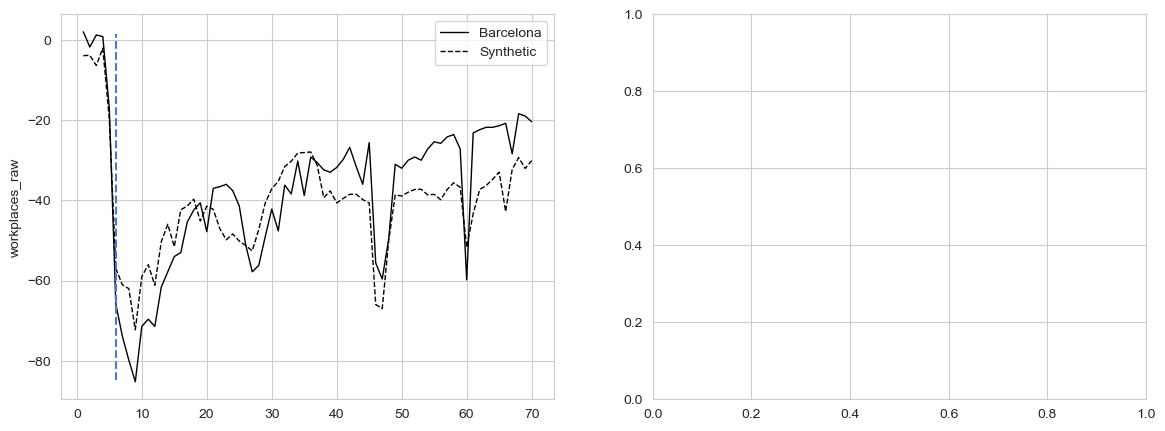

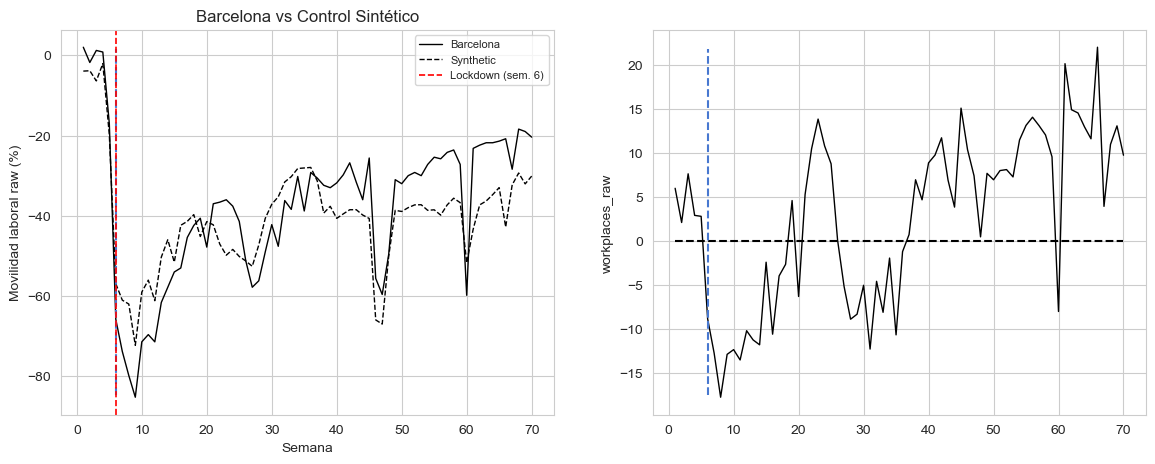

<Figure size 640x480 with 0 Axes>

In [33]:
# Trayectorias y brecha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
synth.path_plot(time_period=range(1, 71), treatment_time=6)
axes[0].set_title('Barcelona vs Control Sintético')
axes[0].set_xlabel('Semana'); axes[0].set_ylabel('Movilidad laboral raw (%)')
axes[0].axvline(x=6, color='red', linestyle='--', linewidth=1.2, label='Lockdown (sem. 6)')
axes[0].legend(fontsize=8)

plt.sca(axes[1])
synth.gaps_plot(time_period=range(1, 71), treatment_time=6)
axes[1].set_title('Brecha: Barcelona real − Control Sintético')
axes[1].set_xlabel('Semana'); axes[1].set_ylabel('Efecto estimado (p.p.)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(x=6, color='red', linestyle='--', linewidth=1.2)

plt.tight_layout()
plt.show()

De lo anterior podemos hacer las siguientes interpretaciones:

**Pesos y balance:** El Synth clásico construye Barcelona sintética con Stockholm (46.5%), Paris (29.1%) y Firenze (24.4%). El PenalizedSynth distribuye más los pesos: Malmö (38.3%), Paris (33.5%), Montpellier (21.7%), con contribuciones menores de Firenze y Stockholm. La combinación de ciudades suecas y francesas es económicamente coherente: Suecia aporta el contrafactual de política laxa y Francia ciudades con estructura económica similar a Barcelona. El balance en predictores es bueno para construcción (0.056 vs 0.055), sex_ratio (107.1 vs 106.7) y desempleo (15.0 vs 14.1), con ajuste más impreciso en la trayectoria pre-tratamiento de movilidad (–3.0 vs –7.2), limitación esperable dado el período pre-tratamiento muy corto (5 semanas).

**Efecto causal estimado:** La brecha entre Barcelona real y su control sintético se amplía bruscamente desde la semana 6, alcanzando un mínimo de aproximadamente –40 a –50 p.p. en las semanas 8–12 (pico del confinamiento estricto). Esto indica que el lockdown redujo la movilidad laboral de Barcelona muy por debajo de lo que habría ocurrido bajo las políticas más laxas de Francia, Italia y Suecia. La brecha se cierra gradualmente durante la desescalada (semanas 15–30), convergiendo hacia cero alrededor de la semana 35, lo que sugiere que la recuperación de movilidad fue completa una vez levantadas las restricciones.

**Limitaciones del diseño:** Dos aspectos limitan la confianza en la magnitud exacta del efecto. Primero, el período pre-tratamiento es de solo 5 semanas (el dataset comienza en febrero 2020), lo que dificulta ajustar bien la trayectoria pre-tratamiento y puede afectar la precisión de los pesos. Segundo, Francia e Italia —que conforman una parte importante del donor pool— también implementaron confinamientos estrictos en las semanas 7–8, lo que compromete parcialmente el SUTVA: el contrafactual sintético también cayó durante el período post-tratamiento, potencialmente subestimando el efecto causal de las restricciones españolas.

**Consistencia con los modelos de panel:** El efecto pico estimado por control sintético (–40 a –50 p.p.) es mayor que el sugerido por los modelos de panel (Stringency +74 puntos × –0.46 ≈ –34 p.p.), lo cual es esperable: los modelos de panel estiman un efecto promedio y lineal sobre todo el período 2020–2022, mientras que el control sintético captura el evento más intenso (el confinamiento de primavera de 2020). Ambas metodologías apuntan en la misma dirección: las restricciones gubernamentales tuvieron un efecto negativo sustancial y robusto sobre la movilidad laboral.